# ICT-MUH — Le texte où Tegmark cite Schmidhuber : cadrage sur banc fini

**Axe transverse — témoin de lecture** | Epic **#4588** | See **#16759** (arc C de **#16741**).

**Navigation** : [README de la série](README.md) | Voisin MDL : [ICT-16](ICT-16-MDLTwoPartCode.ipynb) | Charnière compression : [ICT-17b](ICT-17b-Grokking-CompressionProgress.ipynb) | Cartographie de la tresse : [tresse-cartographie.md](../../../docs/ict/tresse-cartographie.md)

## Pourquoi ce notebook

Max Tegmark, *The Mathematical Universe* (2007, [arXiv:0704.0646](https://arxiv.org/abs/0704.0646)), et Jürgen Schmidhuber (*A Computer Scientist's View of Life*, 1997 ; *Algorithmic Theories of Everything*, 2000) sont les deux inspirations déclarées du programme ICT. Elles se rencontrent **dans le texte fondateur lui-même** : la phrase « *an entire ensemble is often much simpler than one of its members* » (p. 12) cite [17] — précisément Schmidhuber 2000 — et la double référence [13, 17] revient aux pages 18 et 20. C'est l'énoncé le plus pur du geste compression → généralisation qui traverse toute la série (jambe K d'ICT-13/ICT-16, [tresse](../../../docs/ict/tresse-cartographie.md) fibre 1.2).

Ce notebook prend ce texte au sérieux **sans quitter le sol** : chaque concept (triptyque bird/frog/consensus, baggage, ensemble-plus-simple-qu'un-membre, relation R anti-« anything goes », jumeaux premiers calculable vs recherche non garantie) est confronté à une **expérience finie, CPU, réellement calculée** — longueur de description MDL/zlib et invariants sur des bancs finis. Aucune de ces expériences ne porte sur la MUH elle-même : elles mesurent les *gestes* du texte sur des objets assez petits pour être énumérés.

## Plan

1. **Le texte fondateur** : où Tegmark cite Schmidhuber, et où ICT se situe.
2. **Bird / frog / consensus** : le triptyque mappé sur structure externe / représentation interne / vue reconstruite — un banc où la vue reconstruite converge vers la structure externe.
3. **« Reducing the baggage allowance »** : la structure comme invariant de re-description (labellisations différentes, longueur canonique identique).
4. **« An entire ensemble is often much simpler than one of its members »** : banc de cycles où l'ensemble entier coûte moins par membre qu'un membre isolé, et l'index de sélection coûte `ceil(log2(N))` bits.
5. **Anti-« anything goes »** : distiller Adam et Ève en un ensemble `S` et une relation `R` — banc d'énumération où la contrainte réduit l'espace et raccourcit la description.
6. **Jumeaux premiers (Éq. 8-9)** : calculable garanti vs recherche non garantie — un banc qui tranche le prédicat premier et ne peut pas trancher l'énoncé existentiel ; CUH et pseudo-continuum.
7. **Conclusion** : ce que les bancs mesurent, ce qu'ils ne prouvent pas.

**Dépendances** : `ict.compression`, `ict.mdl` (numpy + zlib, bibliothèque standard). Pas de GPU, pas de Lean. Notebook exécutable end-to-end (les exercices sont des stubs sans erreur volontaire, règle C.1).

**Durée estimée** : 35 minutes.

> **Statut épistémique** — **Témoin de lecture, grade C documentaire.** Tegmark n'est **pas** une fibre de la tresse : les quatre fibres restent Thom / Grothendieck / Schmidhuber / Friston ([tresse-cartographie.md, section 1](../../../docs/ict/tresse-cartographie.md)). Le critère posé sur [#16759](https://github.com/jsboige/CoursIA/issues/16759) est sans ambiguïté : **une fibre s'acquiert par un organe, pas par une citation** — et la voie organe pour Tegmark passe par [#16747](https://github.com/jsboige/CoursIA/issues/16747) (organe de série partagé) ou [#16753](https://github.com/jsboige/CoursIA/issues/16753) (formalisation Lean de l'annexe A), pas par ce notebook. Ici : un banc fini qui **exécute des gestes de compression et d'invariants** que le texte décrit. **Ce notebook ne teste pas la MUH** — aucune mesure ci-dessous ne porte sur l'hypothèse elle-même. L'analogie n'est pas une preuve.

## 1. Le texte fondateur : Tegmark cite Schmidhuber

*The Mathematical Universe* (R16 dans le corpus de lecture de l'Epic [#16741](https://github.com/jsboige/CoursIA/issues/16741) ; PDF archivé au gisement bibliographique du projet, sha8 `85712871`) développe la Mathematical Universe Hypothesis (MUH) : la réalité physique externe **est** une structure mathématique, non pas « est décrite par ». Le papier organise les multivers en quatre niveaux (Level I : régions au-delà de l'horizon ; Level II : désinflations ; Level III : mondes d'Everett ; Level IV : toutes les structures mathématiques).

### 1.1 Où les deux inspirations de ICT se rencontrent

Trois ancrages distincts, à ne pas confondre :

- **p. 12, section sur les constantes physiques** : « *As is discussed in more detail in, e.g., [17, 23, 49], an entire ensemble is often much simpler than one of its members* » — où **[17]** est Schmidhuber, *Algorithmic Theories of Everything* (quant-ph/0011122). L'énoncé compression → généralisation qu'ICT-16 section 6.5 a rendu falsifiable sur chaînes de Markov (le code le plus court généralise : pont calibré) est ici cité comme motivation physique.
- **p. 18, « sommes-nous simulés ? »** : « *Tipler [116], Bostrom [117] and Schmidhuber [13, 17] have gone so far as discussing the probability that we are simulated* » — la **double référence [13, 17]**, c'est-à-dire Schmidhuber 1997 et 2000 ensemble.
- **p. 20, section VII (CUH)** : « *Schmidhuber has hypothesized that all halting programs (together with certain non-halting ones) correspond to physical realities [13, 17]* » — même double référence ; Tegmark en **distingue** sa propre hypothèse (CUH : les **relations** qui définissent la structure sont calculables, non pas l'évolution temporelle).

Les références exactes : [13] Schmidhuber 1997 (quant-ph/9904050), [17] Schmidhuber 2000 (quant-ph/0011122). Pour ICT, Schmidhuber est une **fibre déclarée** (compression progressive, Speed Prior, PowerPlay — opérationnalisés dans `ict/beauty.py`) ; Tegmark reste un **témoin** — l'auteur du texte où la thèse de compression rencontre la physique.

### 1.2 Où ICT se situe dans ce texte

La série ICT mesure des trajectoires de structures causales (Φ, F, K et leurs proxys). Le texte de Tegmark offre à cette mesure **cinq gestes** que ce notebook exécute sur banc fini :

| Geste du texte | Chez Tegmark | Côté ICT | Banc (section) |
|---|---|---|---|
| Deux vues d'une même structure | bird / frog / consensus (p. 3-5) | structure externe / représentation interne / vue reconstruite | section 2 |
| Structure dénuée de « baggage » | « devoid of human baggage » (p. 1) | invariance sous re-description, forme canonique | section 3 |
| Ensemble plus simple qu'un membre | Level IV = 0 bits (p. 12, p. 25) | jambe K, MDL deux parties | section 4 |
| Cohérence : relation R sur un ensemble | Adam et Ève distillés en `{s1, s2, s3}` + R (p. 16) | contraintes, invariants | section 5 |
| Frontière calculable garanti / recherche non garantie | jumeaux premiers, Éq. 8-9 (p. 21) ; CUH (p. 20) | bancs à expérience finie | section 6 |

Le rapprochement de chaque ligne est un **acte de lecture (grade C)**, pas une identification établie — la discipline de la [hiérarchie de sobriété](../../../docs/ict/tresse-cartographie.md) de la tresse s'applique à ce tableau comme au reste de la prose ICT.

In [1]:
import os
import sys
import zlib
import math

# Le package ict/ vit à côté de ce notebook (dossier ICT-Series/ict) :
# sans installation éditable, on insère le dossier courant au path.
_IC = os.getcwd()
if _IC not in sys.path:
    sys.path.insert(0, _IC)

import numpy as np
from ict import compression as CMP
from ict import mdl as M

rng = np.random.default_rng(42)
print('numpy chargé')
print('ict.compression chargé (canonical_int_sequence, compressed_length)')
print('ict.mdl chargé (tpm_description_length, prior KT)')

numpy chargé
ict.compression chargé (canonical_int_sequence, compressed_length)
ict.mdl chargé (tpm_description_length, prior KT)


## 2. Bird, frog, consensus : le triptyque sur banc

Tegmark distingue trois façons de voir une même réalité externe (p. 3-5) :

- la vue **bird** (extérieure) : le mathématicien contemple la structure complète — chez lui, un enchevêtrement de spaghetti d'où la dynamique entière est lisible ;
- la vue **frog** (intérieure) : un observateur vivant dedans, qui ne voit qu'une fenêtre locale de la structure ;
- la vue **consensus** : ce que des observateurs frog reconstruisent et partagent — Tegmark la considère comme l'une des questions centrales de la physique théorique (« *if we cannot answer it, then we cannot test a candidate TOE* »).

ICT parle déjà cette langue, avec ses propres noms : **structure externe** (le banc et sa matrice de transition véritable), **représentation interne** (le représentant interne $\hat{p}$ d'ICT-10 à ICT-17, dont la généalogie est documentée), **vue reconstruite** (l'estimation qu'un observateur accumule). Le banc ci-dessous met les trois en présence :

**Protocole.** Le banc « bird » est une chaîne de Markov à 4 états : depuis $s$, transition déterministe vers $(s+1) \bmod 4$ avec probabilité 0,9, sinon remise uniforme (probabilité 0,025 pour chacun des quatre états, cible incluse). L'entropie conditionnelle véritable vaut $H = 0{,}5032$ bits/symbole. Un observateur **frog** n'accède qu'à un préfixe de la trajectoire, de longueur $m$ croissante ; il reconstruit la TPM empirique $\hat{p}$ (comptage). La **vue consensus** est confrontée à un échantillon test fixe (seed indépendant) : surprise $-\log_2 \hat{p}(s'|s)$ par symbole, et longueur de description KT de $\hat{p}$ (les mêmes outils qu'ICT-16).

In [2]:
# Banc du triptyque : la vue reconstruite converge vers la structure externe.
K = 4

def bird_step(s, r):
    # Vue bird : règle véritable du banc (cycle + remise uniforme à 10 %).
    if r.random() < 0.9:
        return (s + 1) % K
    return int(r.integers(0, K))

# TPM véritable (vue bird) et son entropie conditionnelle.
P_true = np.full((K, K), 0.025)
for i in range(K):
    P_true[i, (i + 1) % K] += 0.9
H_true = float(-np.sum(P_true * np.log2(P_true)) / K)

# Trajectoires : train (la vue frog n'en voit qu'un préfixe), test fixe.
rng_train = np.random.default_rng(42)
train = [0]
for _ in range(2000):
    train.append(bird_step(train[-1], rng_train))
rng_test = np.random.default_rng(7)
test = [0]
for _ in range(2000):
    test.append(bird_step(test[-1], rng_test))

def est_tpm(seq, m):
    # Vue consensus : comptage des transitions sur le préfixe observé.
    counts = np.zeros((K, K), dtype=float)
    for a, b in zip(seq[:m], seq[1:m]):
        counts[a, b] += 1.0
    return counts

def nll_per_symbol(counts, seq):
    # Surprise moyenne de la vue reconstruite sur le test (lissage +1/2).
    probs = counts + 0.5
    probs = probs / probs.sum(axis=1, keepdims=True)
    tot = 0.0
    for a, b in zip(seq[:-1], seq[1:]):
        tot += -np.log2(probs[a, b])
    return tot / (len(seq) - 1)

print(f'entropie véritable du banc (bird) : H = {H_true:.4f} bits/symbole')
print()
print(f'{"budget frog m":>13s} {"NLL test":>9s} {"model_bits KT":>14s} {"états vus":>9s}')
budgets = (20, 50, 100, 200, 400, 800, 1600)
nll_by_m = []
for m in budgets:
    c = est_tpm(train, m)
    n = nll_per_symbol(c, test)
    nll_by_m.append(n)
    mb = M.tpm_description_length(c)
    seen = sum(1 for row in c if row.sum() > 0)
    print(f'{m:13d} {n:9.4f} {mb:14.3f} {seen:9d}')
print(f'plancher théorique atteignable : {H_true:.4f} bits/symbole')

entropie véritable du banc (bird) : H = 0.5032 bits/symbole

budget frog m  NLL test  model_bits KT états vus
           20    0.6245        -35.171         4
           50    0.5471        -27.094         4
          100    0.5218        -21.507         4
          200    0.5253         -7.943         4
          400    0.5322          5.073         4
          800    0.5212         23.310         4
         1600    0.5201         41.199         4
plancher théorique atteignable : 0.5032 bits/symbole


La figure suivante trace la surprise de la vue reconstruite en fonction du budget d'observation, avec le plancher théorique (entropie véritable du banc) en pointillés : c'est la courbe frog → consensus → bird du triptyque, sur un objet assez petit pour être exact.

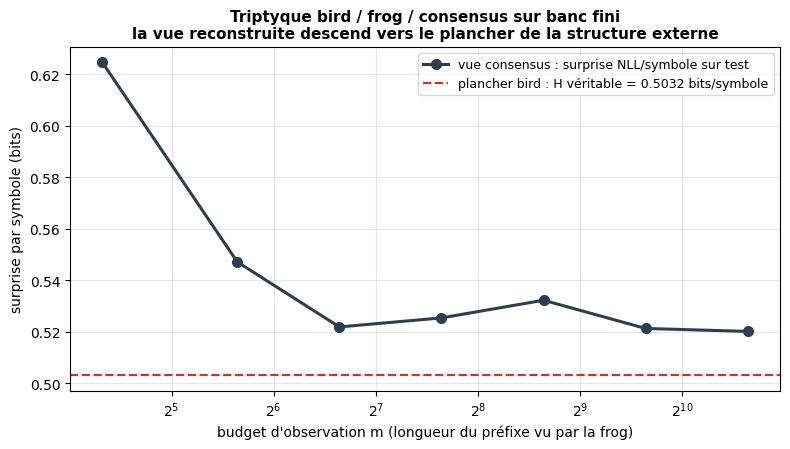

Figure tracée : NLL par budget, plancher H véritable en pointillés.


In [3]:
# Figure : convergence de la vue reconstruite vers la structure externe.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(budgets, nll_by_m, 'o-', color='#2c3e50', lw=2.2, ms=7,
        label='vue consensus : surprise NLL/symbole sur test')
ax.axhline(H_true, color='#c0392b', ls='--', lw=1.6,
           label=f'plancher bird : H véritable = {H_true:.4f} bits/symbole')
ax.set_xscale('log', base=2)
ax.set_xlabel("budget d'observation m (longueur du préfixe vu par la frog)")
ax.set_ylabel('surprise par symbole (bits)')
ax.set_title('Triptyque bird / frog / consensus sur banc fini\n'
             'la vue reconstruite descend vers le plancher de la structure externe',
             fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()
print('Figure tracée : NLL par budget, plancher H véritable en pointillés.')

**Lecture de la sortie, chiffre par chiffre.** La surprise par symbole part de $0{,}6245$ bit à $m=20$ — l'observateur frog a si peu vu que sa TPM reconstruite prédit mal (les cases vides, lissées, coûtent cher) — puis descend par paliers : $0{,}5471$ à $m=50$, $0{,}5218$ à $m=100$, avant de remonter — $0{,}5253$ à $m=200$, $0{,}5322$ à $m=400$ (une transition rare est ré-estimée) — puis de se stabiliser autour de $0{,}520$ bit ($0{,}5212$ à $m=800$, $0{,}5201$ à $m=1600$). Le plancher théorique du banc est $H = 0{,}5032$ bits/symbole : la vue consensus converge vers la structure externe **sans l'atteindre** — l'écart résiduel (~0,017 bit) ne se laisse pas attribuer à une cause unique sans ablation : le lissage (+1/2) sur les transitions rares, biais connu des estimateurs plug-in (déjà signalé par ICT-16 section 3, esprit Miller-Madow), et la réalisation finie de l'échantillon test y contribuent tous deux ; le banc ne les sépare pas.

La colonne `model_bits KT` raconte l'autre moitié du triptyque : la description de $\hat{p}$ **monte** ($-35{,}171$ à $m=20$ vers $+41{,}199$ à $m=1600$) pendant que la surprise descend. C'est le code deux parties d'ICT-16 en acte : plus la vue consensus est informée, plus sa description coûte — les codelengths KT négatives à petit budget sont l'artefact du prior (documenté dans ICT-16 section 1), et c'est la somme modèle + résidu qui arbitre, jamais le modèle seul.

**Ce que le banc ne dit pas.** Il mesure la convergence d'un estimateur statistique sur une chaîne de Markov finie. Rien ici ne porte sur l'ontologie des vues (que la structure « existe » au sens de la MUH) : le triptyque bird/frog/consensus est ici un **moteur de protocole expérimental** — une façon d'organiser (vérité, observation, reconstruction) — pas une thèse.

## 3. « Reducing the baggage allowance » : la structure comme invariant de re-description

La première section du papier pose la contrainte qui gouverne tout le reste : une description de la réalité externe doit être « *devoid of human baggage* » — exprimée dans une forme dénuée de mots humains comme « particule » ou « observation ». Chaque théorie a deux composantes, des équations et du baggage ; distiller une théorie, c'est réduire la seconde tant que la première suffit. C'est littéralement un **quotient** : *mod out the baggage*.

La série ICT connaît ce geste sous un autre nom : une structure est ce qui reste invariant quand on change la description. `ict.compression` l'implémente déjà — `canonical_int_sequence` ré-indexe les étiquettes d'une trajectoire par ordre de première apparition, précisément pour que la mesure de K soit indépendante du choix d'étiquettes. Le banc ci-dessous rend le geste visible : une même trajectoire, trois labellisations arbitraires (chiffres, lettres, noms), deux mesures — la longueur zlib de la sérialisation **brute** (le baggage compte), et la longueur zlib de la forme **canonique** (le baggage est quotienté).

**Protocole.** Trajectoire du banc de la section 2 (600 pas, même règle). Labellisations : `'0'..'3'`, `'a'..'d'`, `'alpha'..'delta'`. Brut : `','.join(etiquettes)` encodé UTF-8 puis zlib niveau 9. Canonique : `CMP.compressed_length` (ré-indexation par première apparition puis zlib). Les écarts affichés sont dérivés des listes mesurées, pas saisis à la main.

In [4]:
# Banc du baggage : même structure, trois habillages, deux mesures.
rng_b = np.random.default_rng(42)
traj = [0]
for _ in range(600):
    traj.append(bird_step(traj[-1], rng_b))

labelings = [('chiffres', ['0', '1', '2', '3']),
             ('lettres', ['a', 'b', 'c', 'd']),
             ('noms',    ['alpha', 'beta', 'gamma', 'delta'])]

z_raw_list, z_canon_list = [], []
print(f'{"labellisation":>13s} {"zlib brut (octets)":>19s} {"zlib canonique (octets)":>24s}')
for name, lm in labelings:
    raw = ','.join(lm[s] for s in traj).encode('utf-8')
    z_raw_list.append(len(zlib.compress(raw, 9)))
    z_canon_list.append(CMP.compressed_length(traj, level=9))
    print(f'{name:>13s} {z_raw_list[-1]:19d} {z_canon_list[-1]:24d}')
print()
print(f"écart max brut      : {max(z_raw_list) - min(z_raw_list)} octets "
      f"(les noms paient leur baggage)")
print(f"écart max canonique : {max(z_canon_list) - min(z_canon_list)} octet "
      f"(invariance de longueur)")

labellisation  zlib brut (octets)  zlib canonique (octets)
     chiffres                  99                       85
      lettres                  99                       85
         noms                 131                       85

écart max brut      : 32 octets (les noms paient leur baggage)
écart max canonique : 0 octet (invariance de longueur)


**Lecture de la sortie.** La sérialisation brute dépend de l'habillage : la même structure coûte $99$ octets habillée en chiffres ou en lettres (même longueur d'étiquette, un octet), et $131$ octets habillée en noms — un écart maximal brut de $32$ octets, payé par le seul choix des étiquettes. La forme canonique, elle, coûte $85$ octets dans les trois cas, un écart nul : ré-indexer par ordre de première apparition a quotienté le choix d'étiquettes, et l'invariance est une égalité de longueur à l'octet près, pas une corrélation approchée.

C'est la version banc, volontairement triviale, d'un geste que la tresse place ailleurs : chez Grothendieck (fibre 1.1), l'invariant est ce qui se recolle quand on change de carte — et la [tresse-cartographie](../../../docs/ict/tresse-cartographie.md) marque précisément que la compression (Schmidhuber) et le recollement (Grothendieck) sont **latéraux, non identiques**. Ici l'invariance est algorithmiquement triviale (une ré-indexation), mais elle est complète et mesurable — la différence entre « le baggage ne compte pas » comme slogan et comme propriété d'une mesure.

**Ce que le banc ne dit pas.** Tegmark vise le baggage *conceptuel* des théories physiques (les postulats en anglais, les mots comme « particule ») ; le banc ne quotientte que le choix d'étiquettes d'une série discrète. Le rapprochement est une métaphore opérationnalisée, pas une réduction.

### Exercice 1 — forme canonique d'une TPM sous permutation d'états

Le banc de la section 3 quotientte le baggage des **séries** (l'ordre des étiquettes). Le baggage des **TPM** est plus riche : deux matrices de transition isomorphes (même dynamique, états ré-étiquetés par une permutation) doivent avoir la même forme canonique — mais la ré-indexation par première apparition n'y suffit pas, car la permutation porte sur les lignes **et** les colonnes simultanément.

Objectif : implémenter `canonical_tpm_key(tpm)` qui retourne une clé invariante sous permutation des états — deux TPM isomorphes (même structure, étiquettes permutées) doivent rendre des clés égales, deux TPM non isomorphes des clés différentes.

**Étape 1** : pour chaque permutation `sigma` de `range(k)` (voir `itertools.permutations`), recalculer la TPM permutée `tpm[sigma[i], sigma[j]]`.
**Étape 2** : sérialiser chaque version (par exemple `np.round(tpm_perm, 6).tobytes()` ou une chaîne formatée) et prendre le **minimum** sur toutes les permutations — la clé canonique.
**Indice** : vérifiez sur une TPM 4x4 aléatoire `A` et sa permutée `A[sigma][:, sigma]` que les clés coïncident, et qu'elles diffèrent de celles d'une TPM aléatoire indépendante. Coût : `k!` permutations — testable jusqu'à `k = 7`.

In [5]:
# Exercice 1 : à compléter
def canonical_tpm_key(tpm):
    """Clé canonique d'une TPM, invariante sous permutation des états.

    Doit retourner un objet hachable (bytes ou str) tel que
    canonical_tpm_key(A) == canonical_tpm_key(A[sigma][:, sigma])
    pour toute permutation sigma des états.
    """
    # TODO étudiant : itérer sur itertools.permutations(range(k)),
    #                 calculer la TPM permutée, la sérialiser, garder le min.
    return None

ex1_result = None  # TODO étudiant : clé de la TPM P_true du banc, puis de la TPM est_tpm(train, 1600)
print("Exercice 1 à compléter")

Exercice 1 à compléter


## 4. « An entire ensemble is often much simpler than one of its members »

L'énoncé le plus célèbre du papier (p. 12), cité à Schmidhuber [17] parmi d'autres, et poussé jusqu'à sa limite au Level IV (p. 25) : « *the ultimate ensemble of the Level IV multiverse would require **0 bits** to specify, since it has no free parameters* » — et « *the algorithmic complexity of a multiverse is not only smaller than for the sum of its parts, but even smaller than for a generic one of its parts* ». Le tout est plus simple qu'une partie générique, parce que spécifier **une** partie coûte la règle **plus** l'index de sélection, alors que spécifier **toutes** les parties ne coûte que la règle.

C'est le pont compression → généralisation dont ICT-16 section 6.5 a montré le versant prédictif (le code le plus court généralise — pont calibré sur chaînes de Markov). Ici, le versant **ensembliste** : sur un banc fini, on peut le mesurer directement.

**Protocole.** Famille $F_p$ : tous les cycles déterministes de période $p$ sur $p$ états distincts — chaque membre est un mot de $p$ symboles commençant par 0, il y en a $N = (p-1)!$. Pour chaque $p$ de 3 à 7 :

- **membre isolé** : le mot répété jusqu'à 60 symboles, compressé zlib (moyenne sur 5 membres tirés avec seed) ;
- **ensemble entier** : les $N$ membres sérialisés et concaténés (60 symboles chacun), compressés zlib une seule fois — rapporté par membre ;
- **index de sélection** : $\lceil \log_2 N \rceil$ bits pour un code de longueur fixe désignant un membre ($\log_2 N$ en est la borne inférieure).

**Précision de périmètre.** La règle $G_p$ qui énumère la famille n'est pas gratuite : la spécifier coûte de l'ordre de $\log_2 p$ bits (dire $p$). Toute la comparaison ci-dessous est donc **conditionnelle à $p$** : à règle donnée, on compare le coût de désigner un membre (l'index) au coût de ne désigner personne (la totalité). zlib est un estimateur brut de $K$ (pas le code optimal — `ict.compression` le documente) ; c'est un estimateur **reproductible et sans paramètre libre**, ce qui suffit pour comparer des longueurs sur un même banc.

In [6]:
# Banc de l'ensemble : décrire tous les cycles vs en décrire un seul.
from itertools import permutations

def serie_from_word(word, L):
    w = list(word)
    out = []
    while len(out) < L:
        out.extend(w)
    return out[:L]

L = 60
print(f'{"p":>2s} {"N=(p-1)!":>9s} {"log2(N)":>8s} {"index_bits":>10s} '
      f'{"iso_bits/membre":>15s} {"ens_bits/membre":>15s} {"gain":>7s}')
iso_by_p, ens_by_p, idx_by_p = [], [], []
for p in (3, 4, 5, 6, 7):
    words = [(0,) + w for w in permutations(range(1, p), p - 1)]
    N = len(words)
    # Membre isolé : moyenne sur 5 membres (seed fixe).
    r_iso = np.random.default_rng(0)
    picks = [words[i] for i in r_iso.choice(N, size=min(5, N), replace=False)]
    iso = float(np.mean([len(zlib.compress(bytes(serie_from_word(w, L)), 9)) * 8.0
                         for w in picks]))
    # Ensemble entier : tous les membres concaténés, une seule compression.
    ens_bytes = b''.join(bytes(serie_from_word(w, L)) for w in words)
    ens = len(zlib.compress(ens_bytes, 9)) * 8.0 / N
    idx_lb = math.log2(N)        # borne inferieure entropique
    idx = math.ceil(idx_lb)      # code de longueur fixe
    gain = 100.0 * (iso - ens) / iso
    iso_by_p.append(iso); ens_by_p.append(ens); idx_by_p.append(idx)
    print(f'{p:2d} {N:9d} {idx_lb:8.3f} {idx:10d} {iso:15.1f} {ens:15.1f} {gain:6.1f}%')

 p  N=(p-1)!  log2(N) index_bits iso_bits/membre ens_bits/membre    gain
 3         2    1.000          1           112.0            68.0   39.3%
 4         6    2.585          3           120.0            42.7   64.4%
 5        24    4.585          5           128.0            27.7   78.4%
 6       120    6.907          7           136.0            23.3   82.8%
 7       720    9.492         10           144.0            31.5   78.2%


La figure suivante met les trois quantités face à face en fonction de $p$ : la description d'un membre isolé, la description de l'ensemble rapportée par membre, et le coût d'index en code de longueur fixe ($\lceil \log_2 N \rceil$, avec ses paliers) — la quantité que le Level IV de Tegmark refuse de payer.

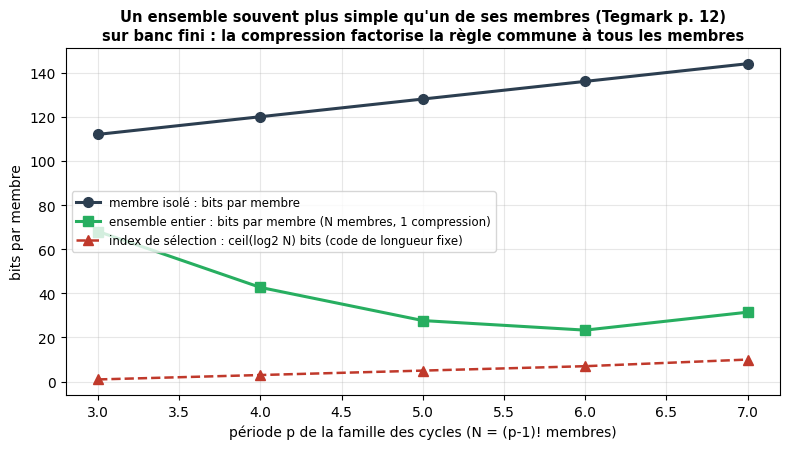

Figure tracée : iso / ensemble / index (code fixe) en fonction de p.


In [7]:
# Figure : ensemble vs membre isolé, et le coût d'index (code fixe).
ps = (3, 4, 5, 6, 7)

fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.plot(ps, iso_by_p, 'o-', color='#2c3e50', lw=2.2, ms=7,
        label='membre isolé : bits par membre')
ax.plot(ps, ens_by_p, 's-', color='#27ae60', lw=2.2, ms=7,
        label='ensemble entier : bits par membre (N membres, 1 compression)')
ax.plot(ps, idx_by_p, '^--', color='#c0392b', lw=1.8, ms=7,
        label='index de sélection : ceil(log2 N) bits (code de longueur fixe)')
ax.set_xlabel('période p de la famille des cycles (N = (p-1)! membres)')
ax.set_ylabel('bits par membre')
ax.set_title("Un ensemble souvent plus simple qu'un de ses membres (Tegmark p. 12)\n"
             'sur banc fini : la compression factorise la règle commune à tous les membres',
             fontsize=10.5, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(loc='center left', fontsize=8.5)
plt.tight_layout()
plt.show()
print('Figure tracée : iso / ensemble / index (code fixe) en fonction de p.')

**Lecture de la sortie, ligne par ligne.** Sur toute la gamme, la description de l'ensemble rapportée par membre est **inférieure** à celle d'un membre isolé — le gain va de $39{,}3\ \%$ ($p=3$) à $82{,}8\ \%$ ($p=6$), et reste à $78{,}2\ \%$ à $p=7$. Le mécanisme se lit dans la colonne des membres isolés : un membre isolé coûte de plus en plus cher ($112$ à $128$ bits de $p=3$ à $p=5$) parce que son mot propre est plus riche ; l'ensemble entier, lui, **factorise** ce qui est commun à tous — être un cycle de période $p$ — une seule fois, et ne paie plus que le contenu propre de chaque mot ($68$ bits par membre à $p=3$, descendant à $23{,}3$ à $p=6$).

La colonne `index_bits` (code de longueur fixe) est la moitié Tegmark de l'histoire : désigner un membre de $F_p$, **la règle $G_p$ étant donnée**, coûte $\lceil \log_2 N \rceil$ bits — $1$ bit à $p=3$, déjà $10$ bits à $p=7$ (borne inférieure $\log_2 N = 9{,}492$) — et ce coût croît comme $\log_2 N \approx p \log p$ (Stirling), bien plus vite que le coût de spécifier la règle elle-même (de l'ordre de $\log_2 p$ bits pour dire $p$). La comparaison est **conditionnelle à $p$** : c'est à règle donnée que sélectionner coûte et que la totalité de la famille ne paie aucun index. Le Level IV = 0 bits pousse ce constat un étage que le banc n'atteint pas : l'ensemble de **toutes** les structures n'a plus de paramètre du tout — ni index, ni même le choix de $p$. Le banc en montre le geste à échelle réduite : la sélection coûte, la totalité ne paie que la règle.

**Ce que le banc ne dit pas.** Il mesure un compresseur réel (zlib) sur des séries finies, pas la complexité de Kolmogorov, et ses familles sont très loin des « structures mathématiques » de Tegmark. Le pont avec la généralisation prédictive (Alexander Principle, arc [#16741](https://github.com/jsboige/CoursIA/issues/16741)) est établi ailleurs (ICT-16 section 6.5) ; ici il est seulement **rappelé**.

### Exercice 2 — le crossover : à partir de quelle taille le générateur gagne-t-il ?

La comparaison de la section 4 oppose deux stratégies pour transmettre $N$ membres : $N$ compressions séparées (bits isolés $\times$ N) contre une seule compression de la concaténation (bits ensemble $\times$ N). Le résultat dépend de la longueur de série $L$ par membre : à $L$ très petit, l'en-tête zlib domine et l'ensemble pourrait perdre ; à $L$ grand, chaque membre isolé se compresse tout seul (sa période est trouvée) et l'avantage de la factorisation commune diminue.

Objectif : tracer le **gain relatif** $100 \cdot (\text{iso} - \text{ens}) / \text{iso}$ de la famille $p = 5$ en fonction de $L \in \{6, 12, 20, 30, 60, 120, 240\}$, et déterminer le $L$ de crossover si la courbe change de signe.

**Étape 1** : reprendre le code de la cellule de la section 4 dans une boucle sur $L$ (même famille $F_5$, même seed pour les membres isolés).
**Étape 2** : tracer gain vs $L$ ; annoter le signe. Si le gain reste positif partout, le dire et interpréter (l'en-tête zlib de la concaténation unique est amorti dès le premier membre).
**Indice** : à $L = p$ précisément (un seul passage du mot), l'isolé n'a aucune périodicité à exploiter — commencez par comprendre ce que zlib y fait.

In [8]:
# Exercice 2 : à compléter
ex2_gains = {}  # L -> gain relatif en %

# TODO étudiant : boucle sur L in (6, 12, 20, 30, 60, 120, 240),
#                 reprendre le protocole p=5, remplir ex2_gains.
print("Exercice 2 à compléter")

Exercice 2 à compléter


## 5. Anti-« anything goes » : distiller Adam et Ève en un ensemble et une relation

L'objection classique au Level IV — « si toutes les structures existent, alors tout se vaut » — reçoit dans le papier une réponse constructive (p. 16, section « The "anything goes" critique ») : prenons la proposition « God created Adam and Eve ». Les mots viennent avec du baggage (connotations, propriétés non explicitées). Distillée en structure mathématique, la proposition devient : un ensemble $S$ à trois éléments, et une relation $R$ telle que $R(s_i, s_j)$ est vraie si et seulement si $i = 1$ et $j \geq 2$. **La cohérence n'est pas négociable** : une fois le baggage quotientté, ce qui reste est un ensemble et des relations — et une structure quelconque, sans relations satisfaites, n'est pas « n'importe quelle histoire ».

Le banc ci-dessous mesure l'effet de ce geste sur l'espace le plus simple qui soit : les **256 règles élémentaires d'automate cellulaire** (entrée = 3 bits, sortie = 1 bit — chaque règle est sa table de vérité, $2^8 = 256$ possibilités). L'« anything goes » correspond au sac des 256 règles, sans rien en commun. Une **relation R** sur cet espace définit un sous-ensemble strict — et raccourcit la description de chaque membre :

- **invariance miroir** : la règle ne distingue pas la gauche de la droite — les entrées $001$ et $100$ donnent la même sortie, de même $011$ et $110$. **Deux paires d'entrées sont identifiées, soit deux bits de description libérés** : la table n'a plus que 6 entrées libres ;
- **totalisticité** : la sortie ne dépend que du **nombre** de cellules vivantes voisines (4 valeurs possibles) — les 8 entrées se réduisent à 4 classes : quatre bits libérés.

Ces contraintes sont l'**analogue local** de la $R$ de Tegmark — l'analogie est de rôle, pas de portée : elles ne disent pas quelle règle est « la bonne », elles disent quelles règles sont **cohérentes avec une symétrie donnée** — et la description d'une règle contrainte est plus courte du nombre de degrés de liberté quotienttés.

In [9]:
# Banc anti-anything-goes : énumération exhaustive des 256 règles élémentaires.
def rule_table(rule):
    # Table de vérité : entrée n = 4*l + 2*c + r (bits gauche, centre, droite),
    # sortie = bit n de l'encodage Wolfram de la règle.
    return [(rule >> n) & 1 for n in range(8)]

n_total, n_mirror, n_totalistic = 0, 0, 0
for rule in range(256):
    t = rule_table(rule)
    n_total += 1
    # Relation R1 : invariance miroir (001 <-> 100, 011 <-> 110).
    if t[1] == t[4] and t[3] == t[6]:
        n_mirror += 1
    # Relation R2 : totalisticité (sortie = f(nombre de 1)).
    sums = {}
    ok = True
    for n in range(8):
        s = ((n >> 2) & 1) + ((n >> 1) & 1) + (n & 1)
        if s in sums and sums[s] != t[n]:
            ok = False
        sums[s] = t[n]
    if ok:
        n_totalistic += 1

print(f'espace total (anything goes)        : {n_total:4d} règles, description 8 bits/règle')
print(f'relation R1 = invariance miroir     : {n_mirror:4d} règles '
      f'({100 * n_mirror / n_total:.2f} %), description 6 bits/règle')
print(f'relation R2 = totalisticité         : {n_totalistic:4d} règles '
      f'({100 * n_totalistic / n_total:.2f} %), description 4 bits/règle')
print()
print('vérification attendue : R1 = 2^6 = 64 (2 paires identifiées, 2 bits), '
      'R2 = 2^4 = 16 (8 entrées -> 4 classes, 4 bits)')

espace total (anything goes)        :  256 règles, description 8 bits/règle
relation R1 = invariance miroir     :   64 règles (25.00 %), description 6 bits/règle
relation R2 = totalisticité         :   16 règles (6.25 %), description 4 bits/règle

vérification attendue : R1 = 2^6 = 64 (2 paires identifiées, 2 bits), R2 = 2^4 = 16 (8 entrées -> 4 classes, 4 bits)


**Lecture de la sortie.** L'énumération exhaustive confirme les comptes attendus : $64 = 2^6$ règles invariantes par miroir sur $256$ ($25\ \%$), $16 = 2^4$ totalistiques ($6{,}25\ \%$). Chaque relation $R$ réduit l'espace du nombre de degrés de liberté qu'elle quotientte : l'invariance miroir identifie **deux** paires d'entrées indépendantes ($\{001,100\}$ et $\{011,110\}$), soit deux bits libérés ($8 \to 6$) ; la totalisticité réduit les 8 entrées à 4 classes, soit quatre bits ($8 \to 4$). La description d'une règle contrainte (6 ou 4 bits) est plus courte par construction — la contrainte est un invariant, et l'invariant est ce qui se décrit sans répéter.

Sur cet espace, l'effet mécanique de la relation est mesuré : même dans l'espace le plus permissif qui soit (toutes les tables de vérité), poser une relation R définit un **sous-espace plus simple à décrire**. C'est une **observation exacte sur ce banc** — qui n'établit pas la thèse anti-« anything goes » de Tegmark (elle porte sur la cohérence relationnelle des structures mathématiques) : le banc en montre le mécanisme local, pas la preuve. L'analogie de cartographie : chez Tegmark, la cohérence relationnelle opère à l'échelle des structures mathématiques ; chez ICT, la hiérarchie de sobriété suit la même pente (une dissociation observée d'abord, un score ensuite, une classe cohomologique seulement avec les prérequis).

**Ce que le banc ne dit pas.** Rien ici ne dit que **notre** univers satisfait une symétrie miroir ou toute autre $R$ particulière — le banc dit seulement : imposer une relation réduit l'espace et raccourcit la description, mécaniquement. L'argument complet de Tegmark (la structure **est** l'univers) reste hors de portée de ce banc.

## 6. Jumeaux premiers (Éq. 8-9) : calculable garanti vs recherche non garantie, le triangle et le CUH

La section VII du papier articule sa frontière la plus technique autour d'un exemple précis (p. 21). Soit $P(a)$ le prédicat « $a$ est premier » : il existe un algorithme qui **termine toujours** (division d'essai bornée par $\sqrt{a}$). Soit maintenant

$$T(n) \equiv (\exists a)\,[(a > n) \wedge P(a) \wedge P(a+2)]$$

— l'énoncé « il existe des jumeaux premiers plus grands que $n$ ». Tegmark note qu'on peut écrire un programme qui **boucle** en testant $a = n+1, n+2, \dots$ et s'arrête en retournant 1 s'il trouve une paire : ce programme évalue correctement $T(n)$ quand il s'arrête, mais **rien ne garantit qu'il s'arrête** — c'est le régime « *no such halting algorithm for its computation has yet been discovered* ».

**Précision de décidabilité.** Ce contraste ne dit **pas** que $T$ serait indécidable. $T(n)$ est un énoncé $\Sigma_1$ (un existentiel sur un prédicat décidable) : le programme de recherche le **semi-décide** — il s'arrête sur la réponse « oui », et ne dit rien sinon. Mais son statut de décidabilité ne s'en déduit pas : si les jumeaux premiers sont en nombre infini, $T(n)$ est vraie pour tout $n$ et la fonction constante vraie la décide ; s'ils sont en nombre fini, avec $p^*$ le plus grand d'entre eux, $T(n) \equiv (n < p^*)$ est décidée par simple comparaison au seuil. **Dans les deux cas, $T$ est donc décidable — l'argument est non constructif** : il garantit l'existence d'un décideur sans le fournir, et personne n'en connaît un aujourd'hui. Ce que le passage illustre est plus fin que « décidable vs indécidable » : c'est la différence entre une fonction **définie par un calcul garanti de terminer** ($P$ — le régime que le CUH retient) et une fonction **définie par recherche sans garantie** ($T$).

Cette frontière organise le **triangle** du papier (p. 19) : structures mathématiques / systèmes formels / calculs, chacun avec son sous-ensemble « agréable » — définis / décidables / haltants. Tegmark dessine un point d'interrogation au centre : peut-être une structure transcendante commune. Et le **CUH** (p. 20) prend parti : *the mathematical structure that is our external physical reality is defined by computable functions* — des relations implémentables comme des calculs garantis de terminer. Parmi ses conséquences, le défi du continu (p. 23) : remplacer les réels par un **pseudo-continuum dénombrable et calculable, comme les nombres algébriques**.

Le rapprochement avec ce dépôt est un sourire de lecture : le triangle de Tegmark a la même forme que les trois axes d'ICT — **Python exécute** (calculs haltants), **Lean décide** (systèmes formels, preuves vérifiées par le noyau), **ICT mesure** (structures sur bancs). C'est une analogie de **cartographie**, pas une identification — et c'est pour la garder honnête qu'on l'exécute sur un banc.

**Protocole.** Deux expériences **distinctes**, à ne pas confondre. (a) Le prédicat $P$ jusqu'à $10^5$ : test borné par $\sqrt{a}$, on recense les jumeaux et on mesure le nombre maximal de divisions d'un test — le régime « garanti de terminer ». (b) La vérification de **instances** de Goldbach : pour chaque pair $n \leq 10^4$, chercher par essais bornés une décomposition $n = p + q$ — chaque instance est résoluble par recherche bornée ; c'est une illustration du régime « instance bornée vs énoncé universel », **différente** du contraste $P$/$T$.

In [10]:
# Banc : (a) prédicat garanti-haltant P ; (b) instances bornées de Goldbach.
def is_prime(n, counter=None):
    # Prédicat P : termine TOUJOURS (boucle bornée par sqrt(n)).
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    d = 3
    while d * d <= n:
        if counter is not None:
            counter[0] += 1
        if n % d == 0:
            return False
        d += 2
    return True

# (a) Prédicat P : borné par construction, mesuré sur toute la gamme.
N_MAX = 100000
max_ops = 0
n_twins = 0
last_twin = 0
for n in range(3, N_MAX - 2):
    c1, c2 = [0], [0]
    p1 = is_prime(n, c1)
    p2 = is_prime(n + 2, c2) if p1 else False
    max_ops = max(max_ops, c1[0] + c2[0])
    if p1 and p2:
        n_twins += 1
        last_twin = n
print('(a) prédicat P — boucle bornée, terminaison garantie :')
print(f'  jumeaux (p, p+2) avec p < 10^5 : {n_twins}, dernier p = {last_twin}')
print(f'  max divisions pour un double-test : {max_ops}'
      f'  (borne sqrt(10^5) = {math.sqrt(N_MAX):.1f})')
print()

# (b) Goldbach : instances bornées — rien à voir avec le statut de T.
worst, n_checked, all_found = 0, 0, True
for n in range(4, 10001, 2):
    tried = 0
    found = False
    for p in range(2, n // 2 + 1):
        tried += 1
        if is_prime(p) and is_prime(n - p):
            found = True
            break
    worst = max(worst, tried)
    n_checked += 1
    if not found:
        all_found = False
print('(b) instances de Goldbach — recherche bornée par instance :')
print(f'  pairs vérifiés n <= 10^4 : {n_checked}, pire nombre d essais pour un n : {worst}')
print(f'  contre-exemple trouvé : {"OUI" if not all_found else "non"}')
print(f'  énoncé universel certifié par le banc : non — {n_checked} instances ne')
print(f'  prouvent pas l absence d un contre-exemple au-delà de 10^4')

(a) prédicat P — boucle bornée, terminaison garantie :
  jumeaux (p, p+2) avec p < 10^5 : 1224, dernier p = 99989
  max divisions pour un double-test : 314  (borne sqrt(10^5) = 316.2)

(b) instances de Goldbach — recherche bornée par instance :
  pairs vérifiés n <= 10^4 : 4999, pire nombre d essais pour un n : 172
  contre-exemple trouvé : non
  énoncé universel certifié par le banc : non — 4999 instances ne
  prouvent pas l absence d un contre-exemple au-delà de 10^4


**Lecture de la sortie.** Le prédicat $P$ termine par construction (boucle bornée par $\sqrt{a}$) et le banc le vérifie sur toute la gamme : $1224$ paires de jumeaux recensées sous $10^5$ (dernier $p = 99989$), et le double-test le plus coûteux n'a exigé que $314$ divisions — sous la borne théorique $\sqrt{10^5} \approx 316{,}2$. C'est le régime « garanti de terminer » du CUH, constaté et non seulement décrété.

La vérification de Goldbach illustre **autre chose, distincte** : chaque instance (un $n$ pair donné) se résout par une recherche bornée — $4999$ pairs vérifiés, pire cas $172$ essais, aucun contre-exemple — mais **l'énoncé universel n'est pas certifié** : aucun nombre fini d'instances ne couvre un « pour tout $n$ ». Ce banc ne fournit **aucune preuve expérimentale** du contraste $P$/$T$ de la section précédente : il montre deux régimes de *vérification* — instance bornée (toujours terminable) et énoncé universel (non couvert par un banc fini). La frontière Éq. 8-9 ($P$ garanti-haltant, $T$ défini par recherche sans garantie, mais décidable non constructivement dans les deux branches — voir la précision plus haut) est un fait de calcul sur les **définitions** ; le banc Goldbach est un fait de **couverture** sur les vérifications. Les deux s'éclairent mutuellement, ils ne se confondent pas.

C'est la motivation du **CUH** telle que le papier la pose : si la structure qui est notre réalité externe est définie par des fonctions calculables garanties de terminer, alors le problème de la mesure (quels univers « comptent », et combien) est allégé — au prix d'exclure les structures définies par des énoncés non calculables, et de traiter le continu comme un pseudo-continuum (les algébriques, dénombrables et calculables, sont ses candidats). La note honnête du papier : le CUH est **restrictif**, avec des avantages réels et des défis sérieux.

**Ce que le banc ne dit pas.** Rien sur la MUH ni sur le CUH comme hypothèses physiques — le banc dit seulement : sur des entiers bornés, un prédicat garanti-haltant se vérifie sur toute la gamme, et des instances bornées ne certifient pas un universel. La distinction est un fait de calcul ; son usage cosmologique est une thèse.

### Exercice 3 — coût de vérification : bornée vs non bornée, mesuré

La cellule précédente affiche deux nombres de pire cas (divisions d'un test de primalité ; essais de décomposition Goldbach) sans tracer leur distribution.

Objectif : implémenter `prime_ops(n)` qui retourne le nombre de divisions effectuées par `is_prime(n)`, tracer `max prime_ops(k)` pour $k \leq 10^4$ par tranches de 100, et vérifier visuellement la **borne en $\sqrt{n}$** ; puis étendre la vérification Goldbach à $n \leq 10^5$ et rapporter le nouveau pire cas d'essais.

**Étape 1** : copier `is_prime` avec compteur (il est déjà instrumenté : passez une liste `c = [0]`).
**Étape 2** : boucle sur les tranches, tracer max par tranche **et** `sqrt(borne de tranche)` en pointillés — les deux courbes doivent rester proches.
**Étape 3** : reprendre la boucle Goldbach jusqu'à $10^5$ (attention au coût : ~30 secondes en pur Python — réduisez à $5 \times 10^4$ si besoin) et rapporter pire cas + temps approximatif par tranche.
**Indice** : pour Goldbach, précalculer un crible booléen `is_p[k]` pour $k \leq 10^5$ rend chaque test O(1) — comparez alors le pire cas d'essais avec et sans crible : c'est la différence entre vérifier une instance et re-vérifier.

In [11]:
# Exercice 3 : à compléter
def prime_ops(n):
    """Nombre de divisions effectuées par is_prime(n) (instrumentée)."""
    # TODO étudiant : appeler is_prime(n, c) avec c = [0], retourner c[0].
    return None

ex3_worst_by_bin = {}  # tranche -> max prime_ops
ex3_goldbach_worst = None  # TODO étudiant : pire cas d'essais jusqu'à la borne choisie
print("Exercice 3 à compléter")

Exercice 3 à compléter


## Conclusion

Ce notebook a pris les **gestes** du texte fondateur et les a exécutés sur des bancs finis, CPU, réellement calculés :

| Geste du texte | Banc | Mesure | Ce que le banc NE prouve PAS |
|---|---|---|---|
| Bird / frog / consensus (p. 3-5) | chaîne de Markov 4 états, budgets croissants | NLL/symbole $0{,}6245 \to 0{,}5201$ ; plancher $H = 0{,}5032$ ; `model_bits` KT qui monte en même temps | la convergence d'un estimateur n'est pas une ontologie des vues |
| Baggage (p. 1) | même trajectoire, 3 labellisations | brut $99$-$131$ octets ; canonique $85$ octets partout ; écarts dérivés des listes mesurées | le quotient des étiquettes n'est pas le quotient des concepts physiques |
| Ensemble plus simple qu'un membre (p. 12, p. 25) | familles de cycles, $p = 3 \dots 7$ | gain $39{,}3\ \%$ à $82{,}8\ \%$ ; index en code fixe $1 \to 10$ bits (borne inférieure $\log_2 N$ : $1{,}0 \to 9{,}492$) | zlib n'est pas $K$ ; la comparaison est conditionnelle à $p$ ; le Level IV = 0 bits reste hors banc |
| Relation R, anti-« anything goes » (p. 16) | 256 règles élémentaires | $64$ miroir ($25\ \%$, 2 paires identifiées = 2 bits), $16$ totalistiques ($6{,}25\ \%$) ; description $8 \to 6 \to 4$ bits | aucune $R$ particulière n'est imposée à notre univers |
| Éq. 8-9, garanti vs recherche (p. 21) | $P$ jusqu'à $10^5$ ; instances Goldbach $\leq 10^4$ | $P$ : $1224$ jumeaux, $314$ divisions max (borne $316{,}2$) ; Goldbach : $4999$ instances vérifiées, universel non couvert | $T$ est semi-décidé par la recherche mais décidable non constructivement (constante ou seuil) ; le banc Goldbach mesure la couverture d'instances, pas le statut de $T$ |

**Le fil unique** : complexité de description et invariants — mesurer combien coûte de décrire, et ce qui ne change pas quand on change la description. C'est la jonction entre la fibre Schmidhuber de la tresse (compression progressive) et le texte de Tegmark, qui la cite pour la physique.

**Statut, redit une dernière fois.** Tegmark est ici un **témoin de lecture** (grade C documentaire), pas une fibre : le critère de [#16759](https://github.com/jsboige/CoursIA/issues/16759) — *une fibre s'acquiert par un organe, pas par une citation* — sera tranché ailleurs ([#16747](https://github.com/jsboige/CoursIA/issues/16747), [#16753](https://github.com/jsboige/CoursIA/issues/16753)). Ce notebook n'apporte aucune preuve ni réfutation de la MUH : les bancs sont des **modèles réduits des gestes du texte**, exécutés sans complaisance.

**Pour aller plus loin** :

- [ICT-16](ICT-16-MDLTwoPartCode.ipynb) — le MDL deux parties, la bosse complexité-entropie, et le pont testé MDL → généralisation (section 6.5).
- [ICT-17b](ICT-17b-Grokking-CompressionProgress.ipynb) — la compression progressive comme signature de l'apprentissage (charnière S4 → S5).
- [tresse-cartographie.md](../../../docs/ict/tresse-cartographie.md) — les quatre fibres, la hiérarchie de sobriété, et le statut témoin/fibre.
- Tegmark, *The Mathematical Universe*, [arXiv:0704.0646](https://arxiv.org/abs/0704.0646) ; Schmidhuber, *Algorithmic Theories of Everything*, quant-ph/0011122.